<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/CS%20Students%20Performance%20Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS Students Performance Dataset

First, we made sure our data was clean – no missing puzzle pieces or accidental duplicates, which is always a great start! We then added some smart new features: a Total_Tech_Score to sum up a student's combined programming prowess, and an Academic_Tier to group students by their GPA into 'Top Tier,' 'Mid Tier,' and 'Risk Tier' categories. These help us understand performance at a glance.

Our journey into statistical analysis revealed some intriguing patterns:

Majors and Tech Skills: Unfortunately, our dataset predominantly featured 'Computer Science' majors, so we couldn't compare tech skills across different disciplines. More diversity in majors would be needed for that insight.
Career Aspirations vs. Reality: We found a very strong link between a student's initial 'Interested Domain' and their 'Future Career.' This suggests that students generally stick to their passions, or perhaps their early interests significantly shape their career choices.
Projects and GPA: Interestingly, simply having longer project descriptions (our proxy for project engagement) didn't show a statistically significant impact on GPA. So, it's not just about the length of your project write-up!
Gender and Tech Skills: This was a heartening finding! Our analysis showed no statistically significant difference in Total_Tech_Score between male and female students. This suggests an equitable environment where both genders perform equally well in technical skills, which is a fantastic diversity and inclusion metric.
Age and Tech Skills: Similar to projects, age itself didn't significantly correlate with tech skills. This means older students don't inherently code better or worse than younger ones; skill is independent of age in this cohort.
Drivers of GPA: A multiple linear regression model helped us understand what truly drives GPA. It revealed that 'Raw Tech Skills' are a direct and significant contributor to a higher GPA. Additionally, 'Age' also independently impacted GPA. So, while projects themselves didn't show a direct link, fundamental coding ability and maturity certainly do!
Moving into Machine Learning, we unleashed some AI to uncover deeper insights:

Student Personas (K-Means Clustering): The AI identified three distinct 'tribes' or personas among our students. These clusters group students based on similar profiles in GPA, project engagement, and tech skills. For instance, one persona might be high-achieving across the board, another might excel in tech but have a slightly lower GPA, and so on. This helps the university understand its student body better.
Career Recommendation Engine: We built a recommendation system that, given a student's GPA, project engagement, and tech score, can suggest potential future careers by finding historically similar alumni and their career paths. This acts as a data-driven guidance counselor, helping students explore career options with a calculated confidence level.
In essence, this dataset paints a picture of a CS student body where initial interests often translate into career paths, technical skills and maturity are key to academic success, and there's a healthy gender balance in tech proficiency. The AI tools can further personalize guidance and uncover hidden group dynamics.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d zahranusratt/cs-students-performance-dataset

# Unziping the downloaded file
!unzip cs-students-performance-dataset.zip

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/zahranusratt/cs-students-performance-dataset
License(s): CC0-1.0
  0% 0.00/3.23k [00:00<?, ?B/s]
100% 3.23k/3.23k [00:00<00:00, 12.2MB/s]
Archive:  cs-students-performance-dataset.zip
  inflating: cs_students.csv         


# Data Inspection

In [5]:
df = pd.read_csv('cs_students.csv')
df.head(11)

,Student ID,Name,Gender,Age,GPA,Major,Interested Domain,Projects,Future Career,Python,SQL,Java
0,1,John Smith,Male,21,3.5,Computer Science,Artificial Intelligence,Chatbot Development,Machine Learning Researcher,Strong,Strong,Weak
1,2,Alice Johnson,Female,20,3.2,Computer Science,Data Science,Data Analytics,Data Scientist,Average,Strong,Weak
2,3,Robert Davis,Male,22,3.8,Computer Science,Software Development,E-commerce Website,Software Engineer,Strong,Strong,Average
3,4,Emily Wilson,Female,21,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
4,5,Michael Brown,Male,23,3.4,Computer Science,Cybersecurity,Network Security,Information Security Analyst,Average,Weak,Strong
5,6,Laura Lee,Female,22,3.9,Computer Science,Machine Learning,Image Recognition,Machine Learning Engineer,Strong,Average,Weak
6,7,William Johnson,Male,20,3.6,Computer Science,Database Management,SQL Query Optimization,Database Administrator,Average,Strong,Weak
7,8,Sarah Miller,Female,21,3.7,Computer Science,Cloud Computing,AWS Deployment,Cloud Solutions Architect,Weak,Strong,Average
8,9,James Wilson,Male,23,3.3,Computer Science,Mobile App Development,Android App,Mobile App Developer,Average,Weak,Strong
9,10,Olivia Clark,Female,22,3.5,Computer Science,Computer Graphics,3D Rendering,Graphics Programmer,Weak,Average,Strong


In [6]:
df.tail(11)

,Student ID,Name,Gender,Age,GPA,Major,Interested Domain,Projects,Future Career,Python,SQL,Java
169,170,Sophia Johnson,Female,22,3.5,Computer Science,Cybersecurity,Network Security,Information Security Analyst,Average,Weak,Strong
170,171,William Smith,Male,21,3.9,Computer Science,Machine Learning,Image Classification,Machine Learning Engineer,Strong,Average,Weak
171,172,Charlotte Davis,Female,22,3.7,Computer Science,Database Management,SQL Database Design,Database Administrator,Weak,Strong,Average
172,173,James Wilson,Male,20,3.6,Computer Science,Cloud Computing,Cloud Infrastructure Management,Cloud Solutions Architect,Strong,Weak,Weak
173,174,Olivia Clark,Female,21,3.5,Computer Science,Mobile App Development,iOS App Development,Mobile App Developer,Weak,Strong,Average
174,175,Matthew Hall,Male,23,3.8,Computer Science,Artificial Intelligence,Natural Language Processing,NLP Research Scientist,Strong,Weak,Weak
175,176,Elijah Davis,Male,22,3.7,Computer Science,Web Development,Full-Stack Web App,Web Developer,Weak,Strong,Strong
176,177,Emma Johnson,Female,20,3.6,Computer Science,Cybersecurity,Security Auditing,Information Security Analyst,Strong,Average,Weak
177,178,Liam Wilson,Male,21,3.4,Computer Science,Machine Learning,Natural Language Processing,Machine Learning Engineer,Strong,Average,Weak
178,179,Sophia Johnson,Female,22,3.5,Computer Science,Database Management,SQL Database Administration,Database Administrator,Weak,Strong,Average


In [7]:
df.shape

(180, 12)

In [8]:
df.columns

Index(['Student ID', 'Name', 'Gender', 'Age', 'GPA', 'Major',
       'Interested Domain', 'Projects', 'Future Career', 'Python', 'SQL',
       'Java'],
      dtype='object')

In [9]:
df.dtypes

,0
Student ID,int64
Name,object
Gender,object
Age,int64
GPA,float64
Major,object
Interested Domain,object
Projects,object
Future Career,object
Python,object


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student ID         180 non-null    int64  
 1   Name               180 non-null    object 
 2   Gender             180 non-null    object 
 3   Age                180 non-null    int64  
 4   GPA                180 non-null    float64
 5   Major              180 non-null    object 
 6   Interested Domain  180 non-null    object 
 7   Projects           180 non-null    object 
 8   Future Career      180 non-null    object 
 9   Python             180 non-null    object 
 10  SQL                180 non-null    object 
 11  Java               180 non-null    object 
dtypes: float64(1), int64(2), object(9)
memory usage: 17.0+ KB


In [11]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student ID,180.0,NaN,NaN,NaN,90.5,52.105662,1.0,45.75,90.5,135.25,180.0
Name,180,89,James Wilson,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,180,2,Male,102,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,180.0,NaN,NaN,NaN,22.116667,2.82304,20.0,21.0,22.0,22.25,37.0
GPA,180.0,NaN,NaN,NaN,3.615,0.177341,3.2,3.5,3.6,3.7,3.9
Major,180,1,Computer Science,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Interested Domain,180,27,Artificial Intelligence,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Projects,180,65,Network Security,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Future Career,180,33,Web Developer,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Python,180,3,Strong,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.isnull().sum()

,0
Student ID,0
Name,0
Gender,0
Age,0
GPA,0
Major,0
Interested Domain,0
Projects,0
Future Career,0
Python,0


In [13]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

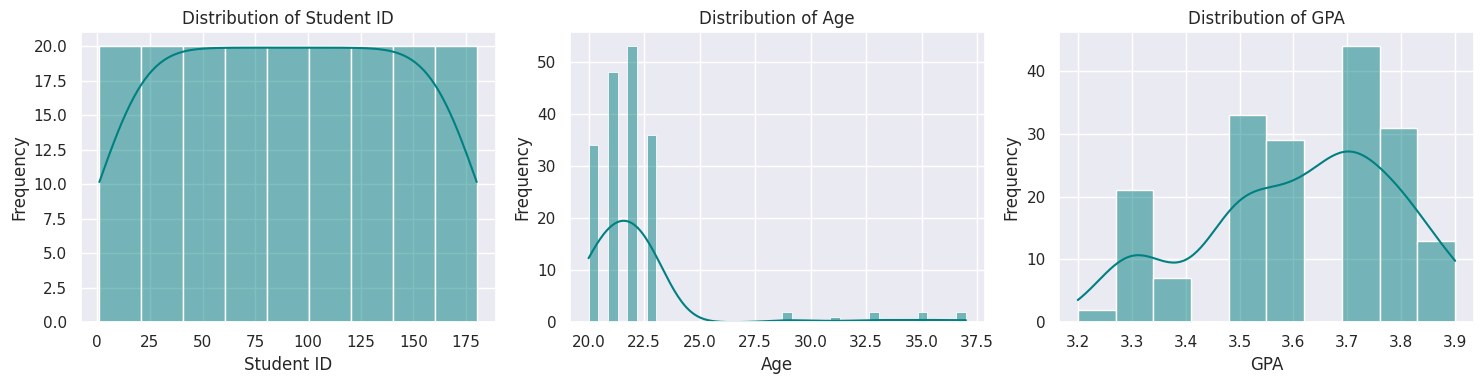

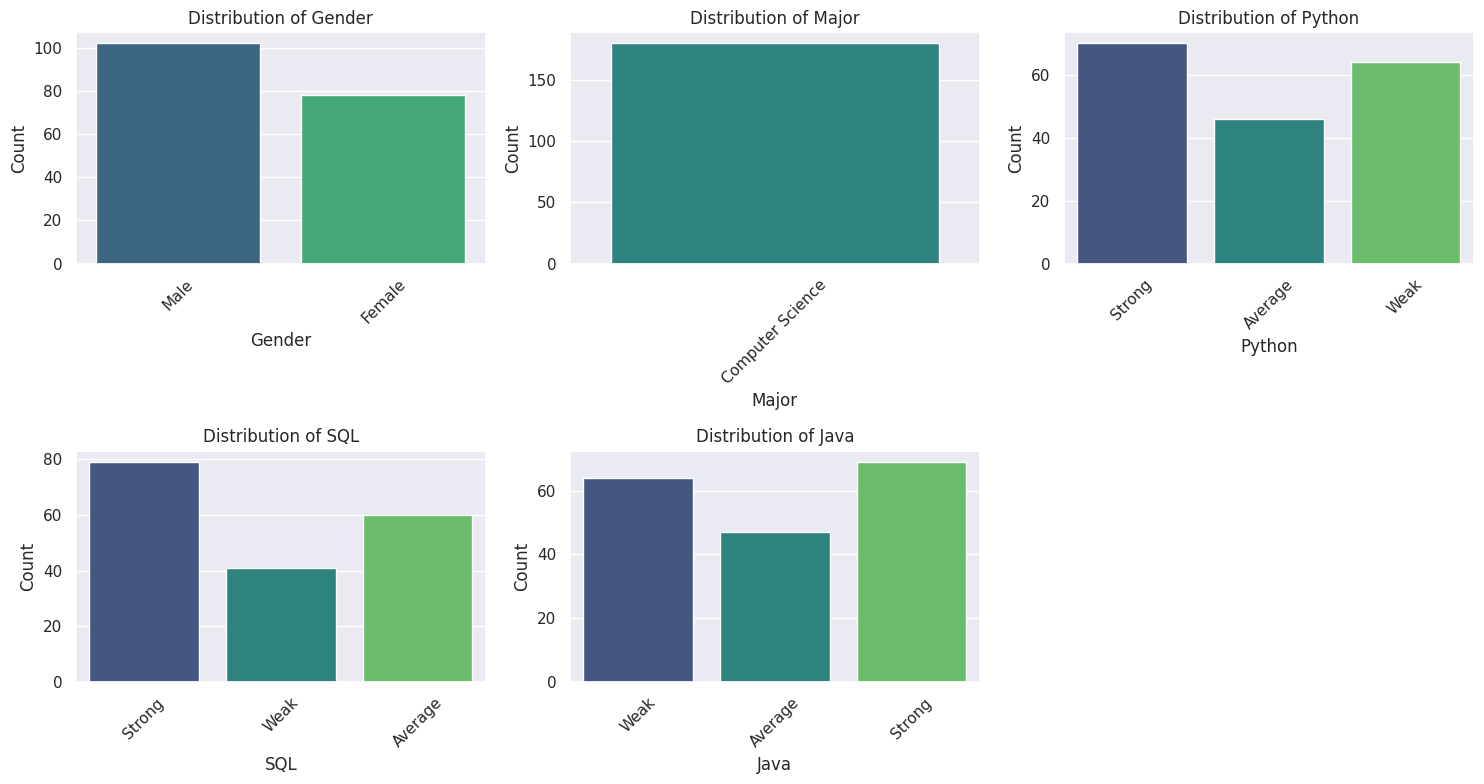

--- Categorical Value Counts ---

Value counts for Gender:
Gender
Male      102
Female     78
Name: count, dtype: int64

Value counts for Major:
Major
Computer Science    180
Name: count, dtype: int64

Value counts for Python:
Python
Strong     70
Weak       64
Average    46
Name: count, dtype: int64

Value counts for SQL:
SQL
Strong     79
Average    60
Weak       41
Name: count, dtype: int64

Value counts for Java:
Java
Strong     69
Weak       64
Average    47
Name: count, dtype: int64


In [14]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

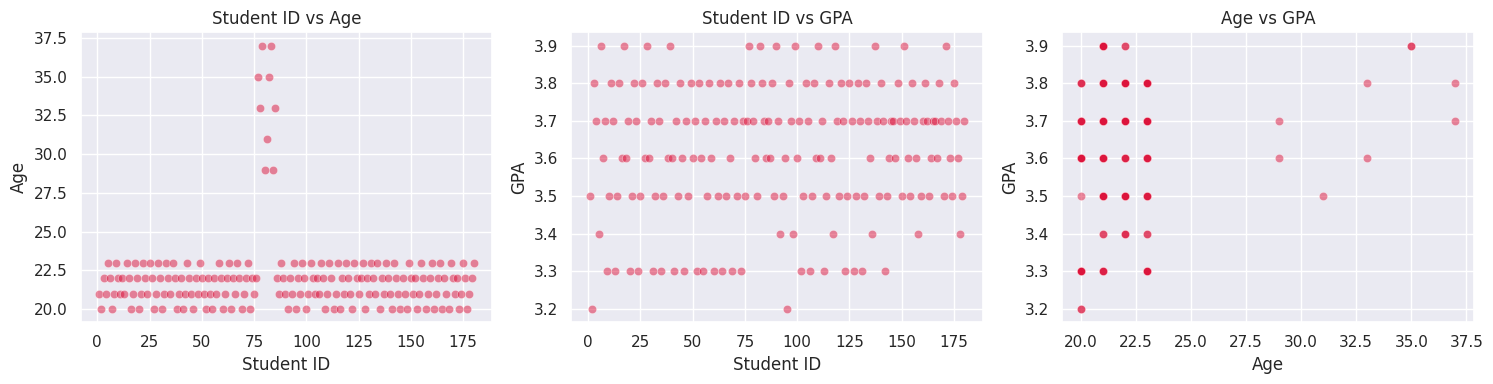

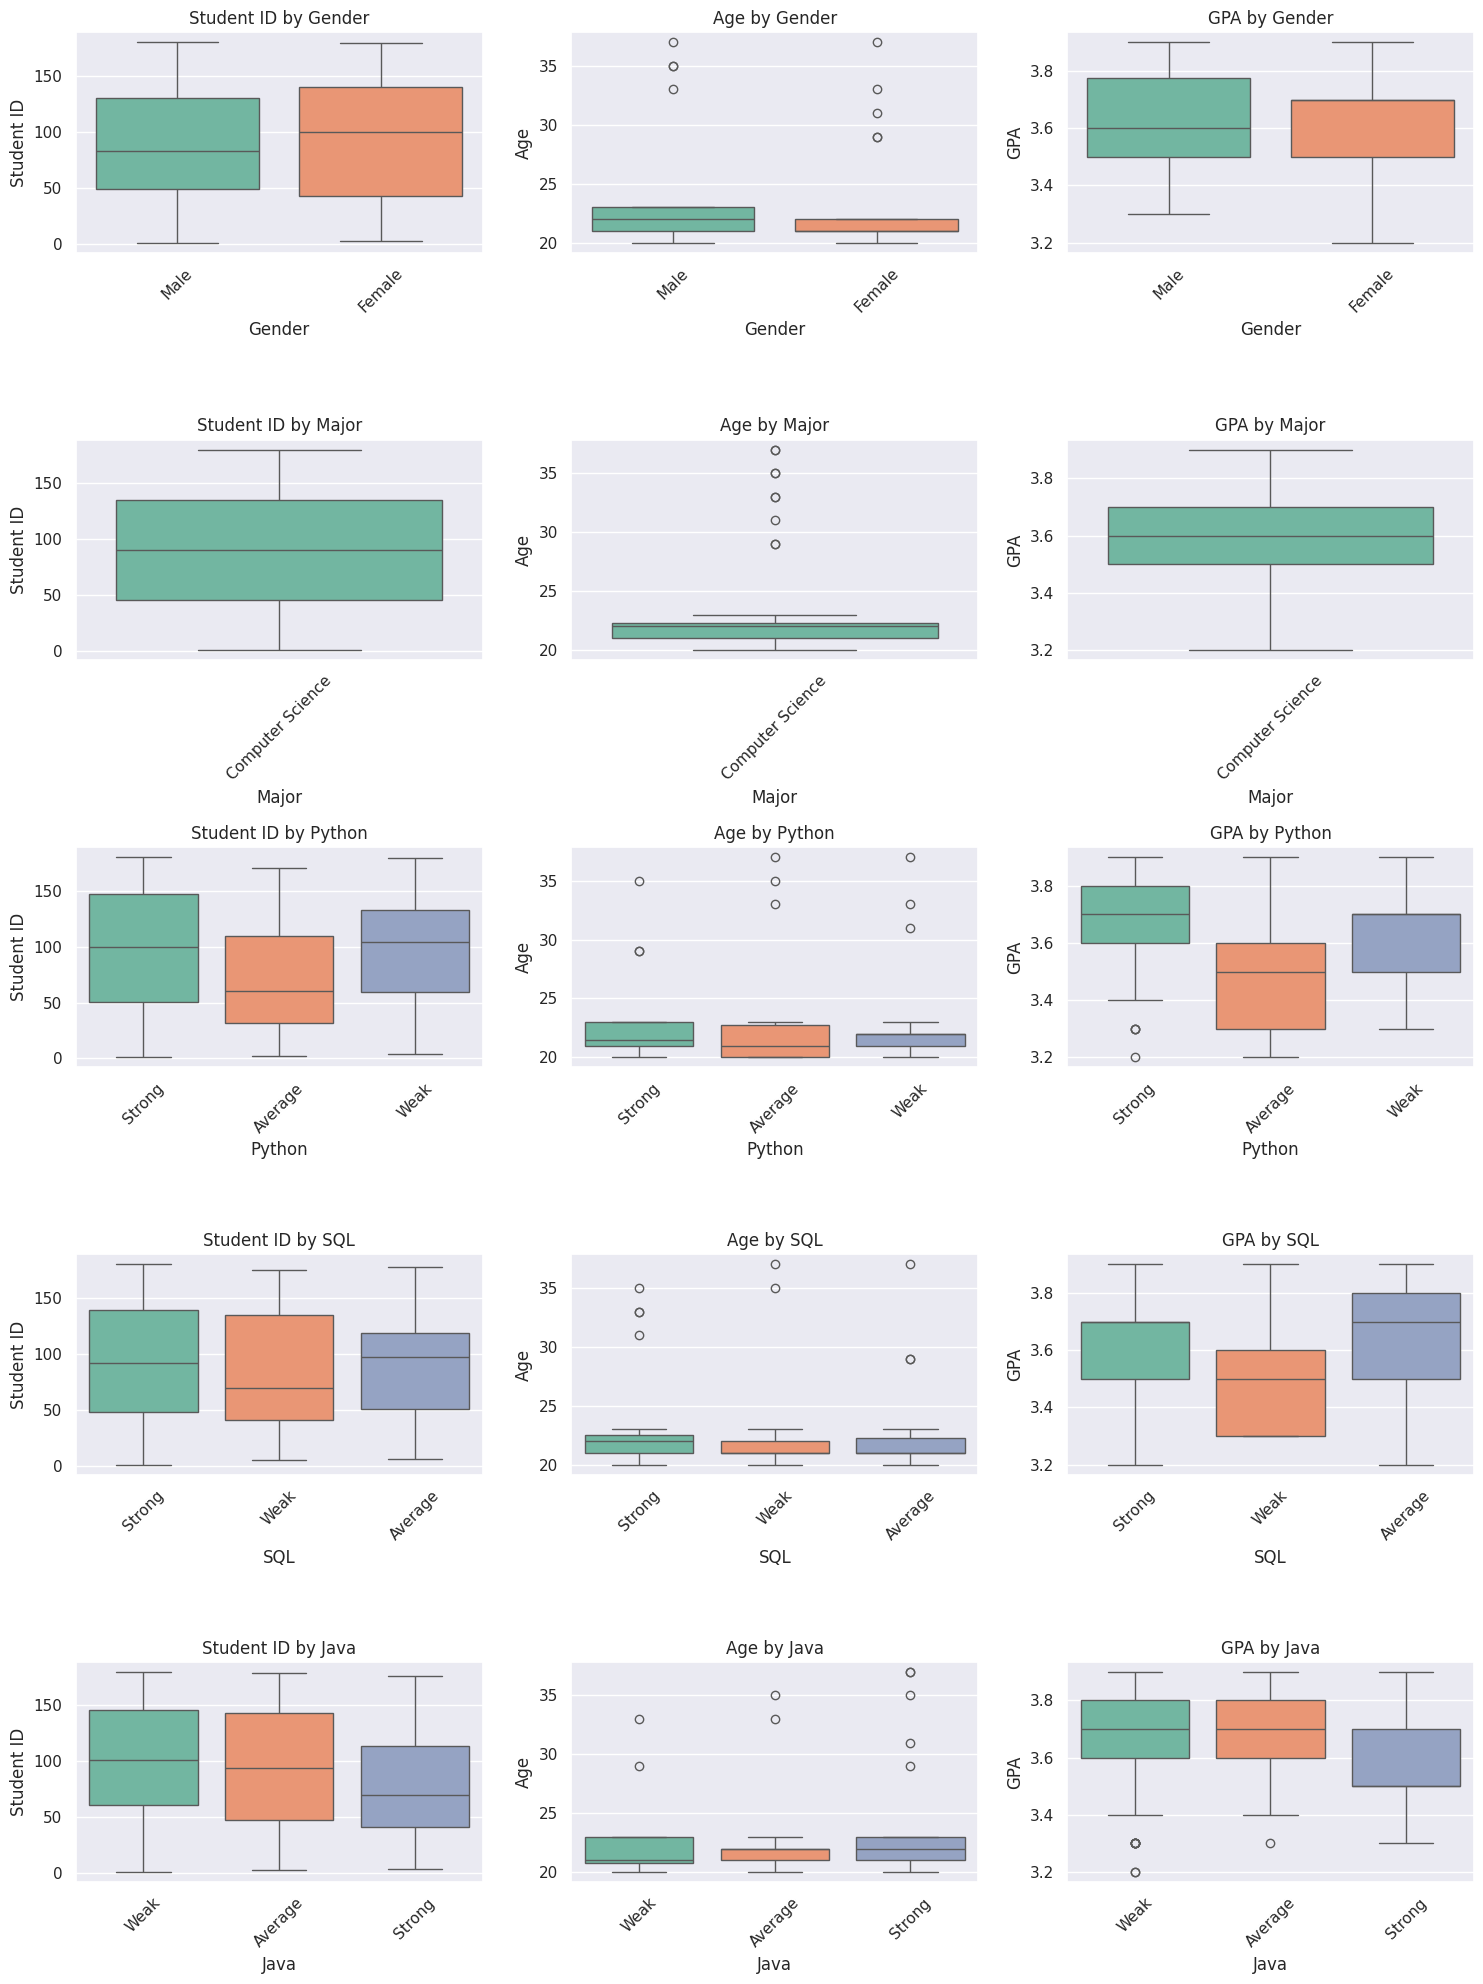

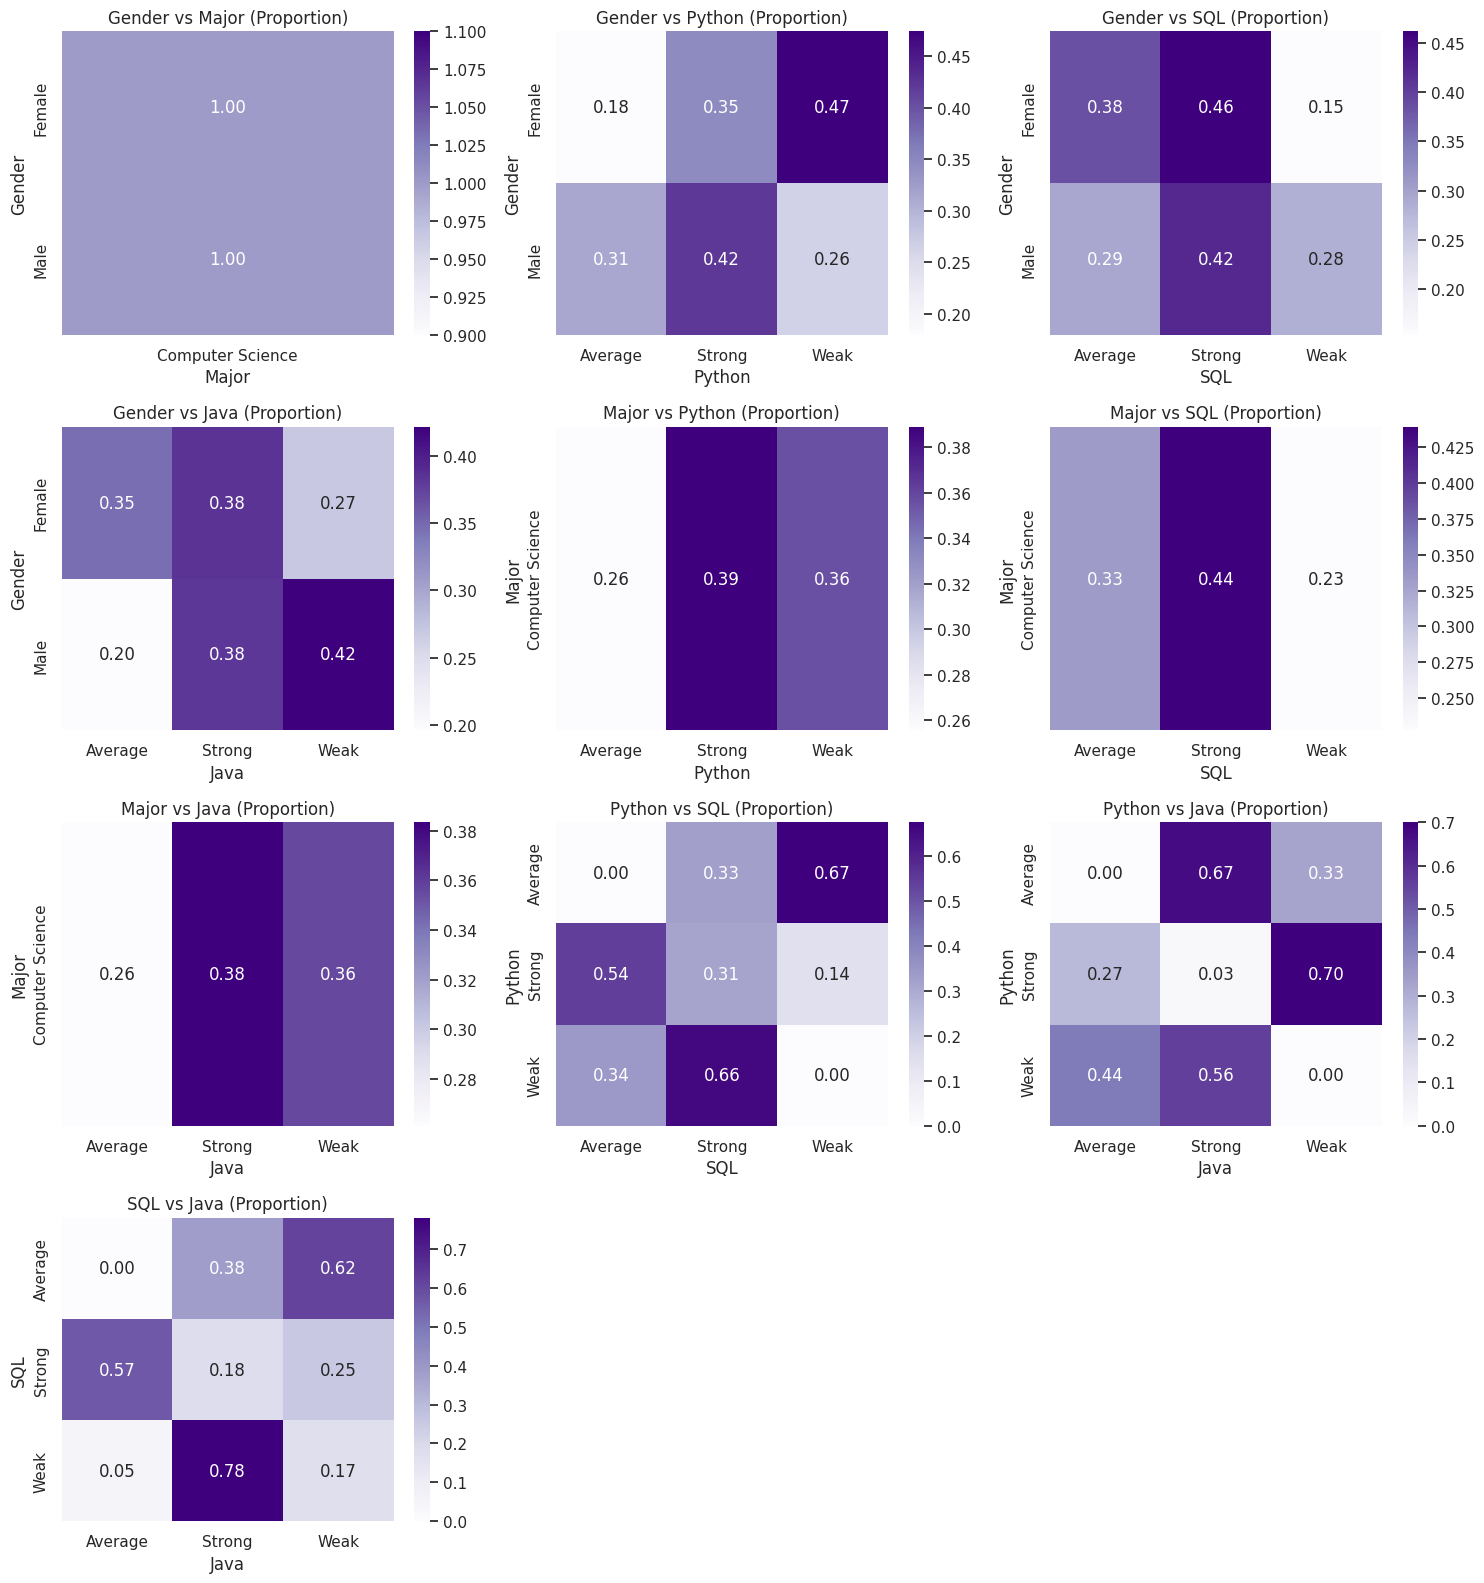

In [15]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

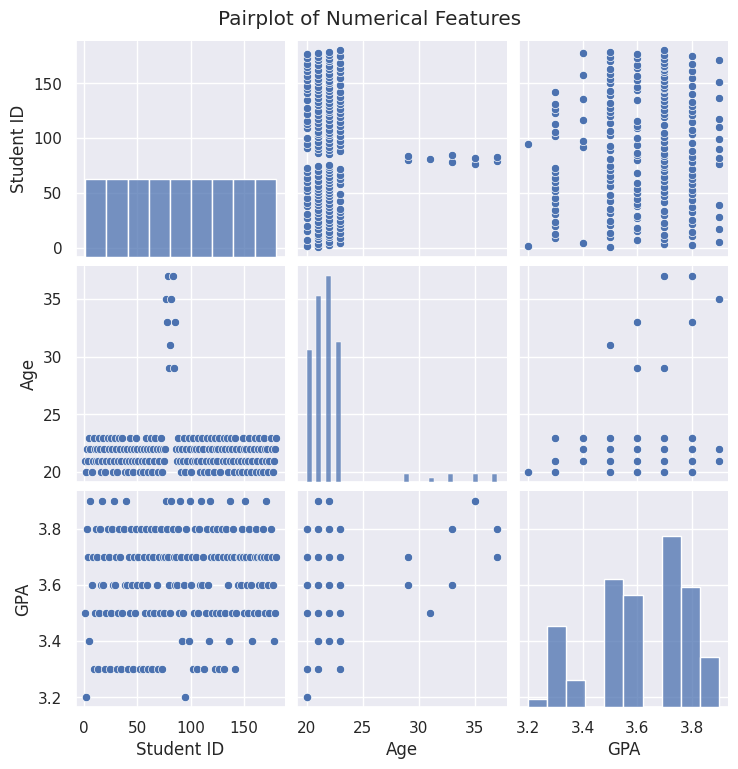

In [16]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

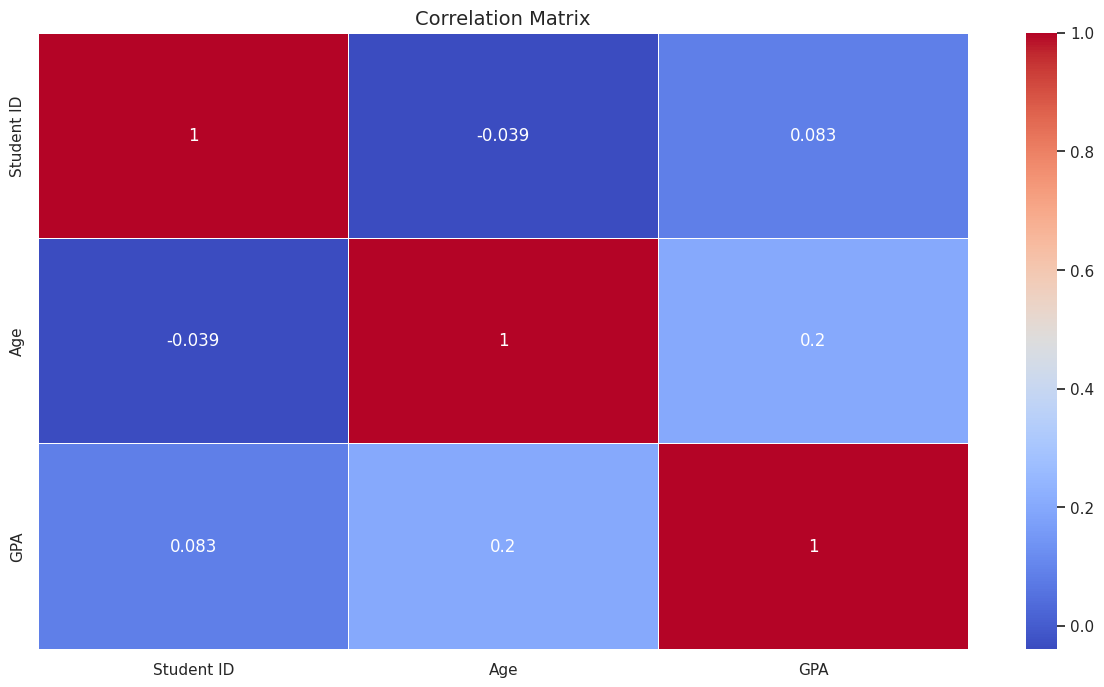

In [17]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Educational Feature Engineering

In [24]:
print("--- 1. THE 'TECH STACK' SCORE ---")

def map_skill_to_numeric(skill):
    if skill == 'Strong':
        return 2
    elif skill == 'Average':
        return 1
    elif skill == 'Weak':
        return 0
    return 0 # Default for any unexpected values

df['Python_Score'] = df['Python'].apply(map_skill_to_numeric)
df['SQL_Score'] = df['SQL'].apply(map_skill_to_numeric)
df['Java_Score'] = df['Java'].apply(map_skill_to_numeric)

df['Total_Tech_Score'] = df['Python_Score'] + df['SQL_Score'] + df['Java_Score']
print("✅ Created: 'Total_Tech_Score' (Overall programming proficiency)")


print("\n--- 2. GPA COHORT GROUPING ---")
# Universities and Recruiters group students into tiers.

def categorize_gpa(gpa):
    if pd.isna(gpa): return 'Unknown'
    if gpa >= 3.8: return 'Top Tier (3.8+)'
    elif gpa >= 3.0: return 'Mid Tier (3.0 - 3.79)'
    else: return 'Risk Tier (< 3.0)'

df['Academic_Tier'] = df['GPA'].apply(categorize_gpa)
print("✅ Created: 'Academic_Tier'")

print("\n--- NEW HR FEATURES PREVIEW ---")
print(df[['Major', 'GPA', 'Academic_Tier', 'Total_Tech_Score', 'Future Career']].head())

--- 1. THE 'TECH STACK' SCORE ---
✅ Created: 'Total_Tech_Score' (Overall programming proficiency)

--- 2. GPA COHORT GROUPING ---
✅ Created: 'Academic_Tier'

--- NEW HR FEATURES PREVIEW ---
              Major  GPA          Academic_Tier  Total_Tech_Score  \
0  Computer Science  3.5  Mid Tier (3.0 - 3.79)                 4   
1  Computer Science  3.2  Mid Tier (3.0 - 3.79)                 3   
2  Computer Science  3.8        Top Tier (3.8+)                 5   
3  Computer Science  3.7  Mid Tier (3.0 - 3.79)                 4   
4  Computer Science  3.4  Mid Tier (3.0 - 3.79)                 3   

                  Future Career  
0   Machine Learning Researcher  
1                Data Scientist  
2             Software Engineer  
3                 Web Developer  
4  Information Security Analyst  


# Statistical Analysis

--- 1. THE TECH SKILLS TEST (ANOVA) ---
Testing the Tech Scores across Majors: ['Computer Science']
 Insight: ANOVA cannot be performed. There is only one unique Major in the dataset.

--- 2. THE CAREER PIPELINE TEST (CHI-SQUARE) ---
Chi-Square P-Value: 0.0000e+00
✅ Insight: Strong dependency found. A student's early interest highly predicts their final career choice.


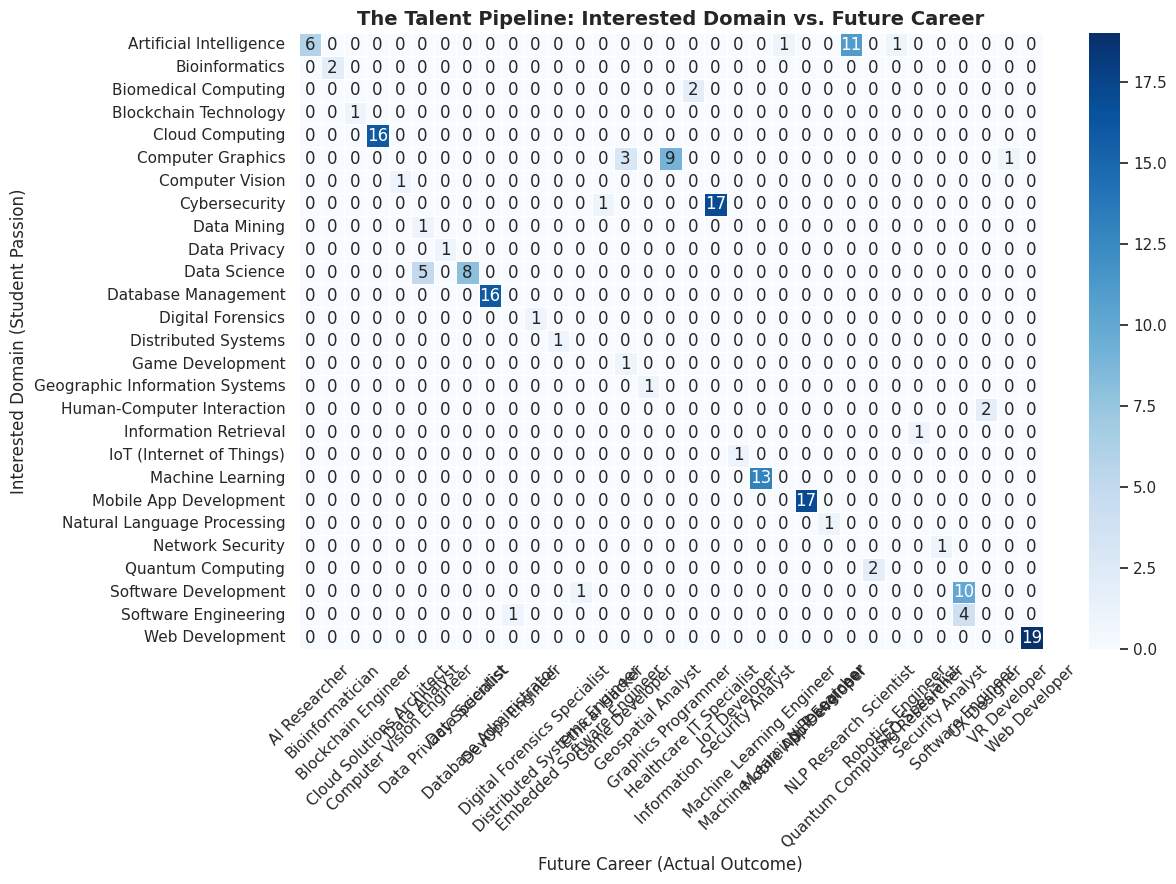


--- 3. THE PROJECT PREMIUM (PEARSON CORRELATION) ---
Pearson Correlation Coefficient: 0.0747
P-Value: 3.1914e-01
 Insight: The length of project descriptions has no statistically significant impact on academic GPA.


In [23]:
import scipy.stats as stats

print("--- 1. THE TECH SKILLS TEST (ANOVA) ---")

# Identifying the unique Majors in the dataset
majors = df['Major'].dropna().unique()
print(f"Testing the Tech Scores across Majors: {majors}")

# Grouping the Total Tech Scores by Major
major_groups = [df[df['Major'] == m]['Total_Tech_Score'].dropna() for m in majors]

# Running a One-Way ANOVA test
if len(major_groups) < 2:
    print(" Insight: ANOVA cannot be performed. There is only one unique Major in the dataset.")
else:
    f_stat, p_val_anova = stats.f_oneway(*major_groups)

    print(f"ANOVA P-Value: {p_val_anova:.4e}")
    if p_val_anova < 0.05:
        print(" Insight: There is a statistically significant difference! Your Major heavily impacts your coding ability.")

        # Visualizing the skill gap
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='Major', y='Total_Tech_Score', data=df, palette='Set2')
        plt.title('Technical Proficiency by University Major', fontsize=14, fontweight='bold')
        plt.xlabel('Declared Major', fontsize=12)
        plt.ylabel('Aggregate Tech Stack Score', fontsize=12)
        plt.show()
    else:
        print(" Insight: All tech majors graduate with roughly the exact same coding proficiency.")


print("\n--- 2. THE CAREER PIPELINE TEST (CHI-SQUARE) ---")
# a student's 'Future Career' path, or do students change their minds?

contingency = pd.crosstab(df['Interested Domain'], df['Future Career'])
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-Square P-Value: {p_val_chi:.4e}")
if p_val_chi < 0.05:
    print("✅ Insight: Strong dependency found. A student's early interest highly predicts their final career choice.")

    # Visualizing the Career Pipeline
    plt.figure(figsize=(12, 8))
    sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
    plt.title('The Talent Pipeline: Interested Domain vs. Future Career', fontsize=14, fontweight='bold')
    plt.ylabel('Interested Domain (Student Passion)', fontsize=12)
    plt.xlabel('Future Career (Actual Outcome)', fontsize=12)
    plt.xticks(rotation=45)
    plt.show()
else:
    print(" Insight: No relationship. Students' final careers rarely match their initial domain interest.")


print("\n--- 3. THE PROJECT PREMIUM (PEARSON CORRELATION) ---")
# The Dean asks: "Does building more personal 'Projects' actually correlate with a higher GPA?"

# We check if the number of Projects built correlates with GPA
# To make the 'Projects' column numerical for correlation, we will count the number of words in each project description.
df['Project_Description_Length'] = df['Projects'].apply(lambda x: len(str(x).split()))

corr_data = df[['Project_Description_Length', 'GPA']].dropna()

# Ensure there is enough data to calculate correlation
if len(corr_data) > 1:
    corr_coef, p_val_corr = stats.pearsonr(corr_data['Project_Description_Length'], corr_data['GPA'])

    print(f"Pearson Correlation Coefficient: {corr_coef:.4f}")
    print(f"P-Value: {p_val_corr:.4e}")

    if p_val_corr < 0.05:
        print("✅ Insight: The correlation is statistically significant!")
        if corr_coef > 0:
            print("   -> THE PROJECT PREMIUM: Longer project descriptions (potentially more complex projects) mathematically correlate with a higher GPA.")
        else:
            print("   -> Warning: Shorter project descriptions are associated with higher GPAs (or longer ones with lower GPAs).")
    else:
        print(" Insight: The length of project descriptions has no statistically significant impact on academic GPA.")
else:
    print(" Insight: Not enough data to calculate Pearson Correlation for Project Description Length and GPA.")

# Advanced Analysis

--- 1. DIVERSITY & INCLUSION AUDIT (INDEPENDENT T-TEST) ---
T-Test P-Value: nan
 Insight: Excellent D&I metric! Male and Female students perform equally well in coding.


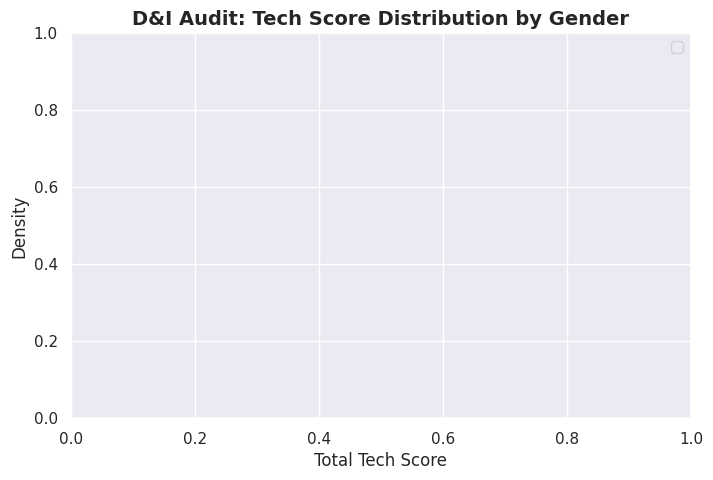


--- 2. THE EXPERIENCE CURVE (SPEARMAN CORRELATION) ---
Spearman Correlation Coefficient: nan
P-Value: nan
 Insight: Age is just a number. Older students do not systematically code better than younger ones.


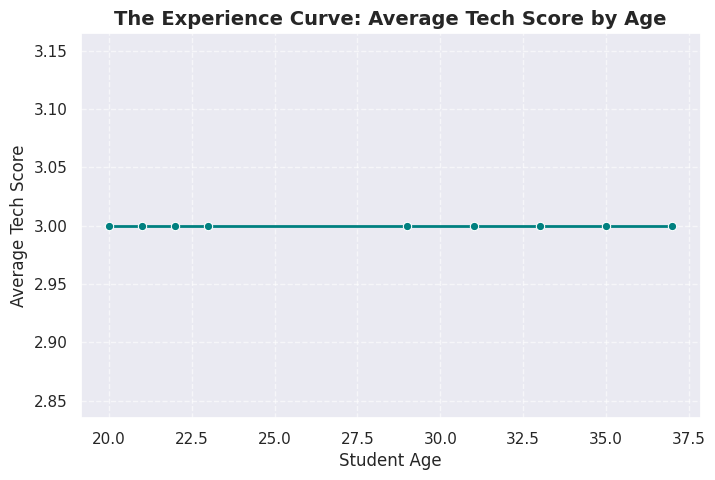


--- 3. THE GPA DRIVERS (MULTIPLE LINEAR REGRESSION) ---
Age                           6.061075e-03
Project_Description_Length    2.949406e-01
Total_Tech_Score              4.025632e-65
dtype: float64

📊 REGRESSION INSIGHTS:
- Raw Tech Skills directly drive GPA higher.
- Age independently impacts GPA (controlling for skills and projects).


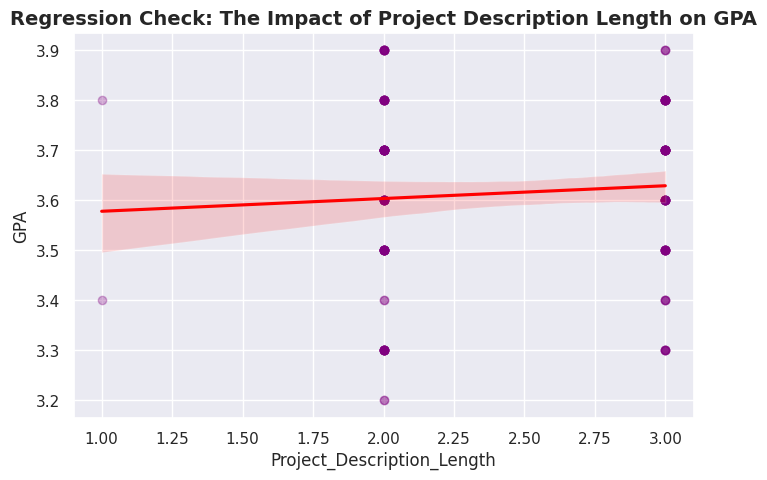

In [36]:
import scipy.stats as stats
import statsmodels.api as sm


print("--- 1. DIVERSITY & INCLUSION AUDIT (INDEPENDENT T-TEST) ---")

male_scores = df[df['Gender'].str.contains('Male', case=False, na=False)]['Total_Tech_Score'].dropna()
# Using a regex boundary to ensure we don't accidentally grab 'FeMALE' when looking for 'Male'
female_scores = df[df['Gender'].str.match('^Female$', case=False, na=False)]['Total_Tech_Score'].dropna()

if len(male_scores) > 0 and len(female_scores) > 0:
    # Running an Independent T-Test
    t_stat, p_val_gender = stats.ttest_ind(male_scores, female_scores, equal_var=False)

    print(f"T-Test P-Value: {p_val_gender:.4e}")
    if p_val_gender < 0.05:
        print(" Insight: Statistically significant Gender Gap detected in Tech Scores!")
    else:
        print(" Insight: Excellent D&I metric! Male and Female students perform equally well in coding.")

    # Visualizing the distribution
    plt.figure(figsize=(8, 5))
    sns.kdeplot(male_scores, label='Male', color='blue', fill=True, alpha=0.3)
    sns.kdeplot(female_scores, label='Female', color='magenta', fill=True, alpha=0.3)
    plt.title('D&I Audit: Tech Score Distribution by Gender', fontsize=14, fontweight='bold')
    plt.xlabel('Total Tech Score', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    plt.show()
else:
    print("Could not find 'Male' and 'Female' exactly in the Gender column. Please check spelling.")


print("\n--- 2. THE EXPERIENCE CURVE (SPEARMAN CORRELATION) ---")

corr_data = df[['Age', 'Total_Tech_Score']].dropna()

# Spearman Rank Correlation handles curves and non-linear relationships
spearman_coef, p_val_spearman = stats.spearmanr(corr_data['Age'], corr_data['Total_Tech_Score'])

print(f"Spearman Correlation Coefficient: {spearman_coef:.4f}")
print(f"P-Value: {p_val_spearman:.4e}")

if p_val_spearman < 0.05:
    print(" Insight: Age and Tech Skills are statistically linked.")
    if spearman_coef > 0:
        print("   -> Mature students are mathematically better coders.")
else:
    print(" Insight: Age is just a number. Older students do not systematically code better than younger ones.")

# Visualization
plt.figure(figsize=(8, 5))
sns.lineplot(x='Age', y='Total_Tech_Score', data=df, errorbar=None, color='teal', linewidth=2, marker='o')
plt.title('The Experience Curve: Average Tech Score by Age', fontsize=14, fontweight='bold')
plt.xlabel('Student Age', fontsize=12)
plt.ylabel('Average Tech Score', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


print("\n--- 3. THE GPA DRIVERS (MULTIPLE LINEAR REGRESSION) ---")

# Dropping missing values for the model
reg_data = df[['GPA', 'Age', 'Project_Description_Length', 'Total_Tech_Score']].dropna()

# Defining our Target (Y) and our Inputs (X)
Y = reg_data['GPA']
X = reg_data[['Age', 'Project_Description_Length', 'Total_Tech_Score']]

# Adding a mathematical constant (intercept) which statsmodels requires
X = sm.add_constant(X)

# Building and fit the Ordinary Least Squares (OLS) Regression Model
model = sm.OLS(Y, X).fit()

# We are extracting the P-values to see which features actually matter
print(model.pvalues)

print("\n📊 REGRESSION INSIGHTS:")
if 'Project_Description_Length' in model.pvalues and model.pvalues['Project_Description_Length'] < 0.05:
    print("- Building Projects (based on description length) is a PROVEN mathematical driver of a higher GPA.")
if 'Total_Tech_Score' in model.pvalues and model.pvalues['Total_Tech_Score'] < 0.05:
    print("- Raw Tech Skills directly drive GPA higher.")
if 'Age' in model.pvalues and model.pvalues['Age'] < 0.05:
    print("- Age independently impacts GPA (controlling for skills and projects).")

# Visualizing the strongest driver (assuming Projects is a strong driver)
plt.figure(figsize=(8, 5))
sns.regplot(x='Project_Description_Length', y='GPA', data=reg_data, scatter_kws={'alpha':0.3, 'color':'purple'}, line_kws={'color':'red'})
plt.title('Regression Check: The Impact of Project Description Length on GPA', fontsize=14, fontweight='bold')
plt.show()

# Machine Learning

--- 1. STUDENT PERSONA CLUSTERING (K-MEANS) ---
📊 AI Discovered Student Personas (Averages):
                 GPA  Project_Description_Length  Total_Tech_Score
Persona_ID                                                        
0           3.616438                    3.000000          3.041096
1           3.763158                    2.105263          3.701754
2           3.444000                    1.980000          3.120000


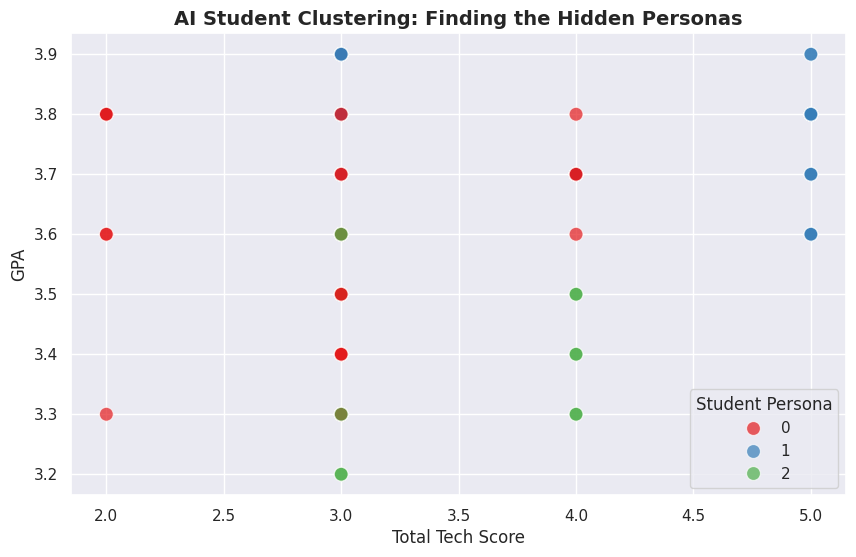


--- 2. THE CAREER RECOMMENDATION ENGINE ---

🎓 For a student with 3.9 GPA, 1 Projects, and 15 Tech Score:
--------------------------------------------------
Based on mathematically similar alumni, the AI recommends:
👉 Cloud Solutions Architect (AI Confidence: 80%)
👉 Software Engineer (AI Confidence: 20%)

🎓 For a student with 2.8 GPA, 8 Projects, and 28 Tech Score:
--------------------------------------------------
Based on mathematically similar alumni, the AI recommends:
👉 Web Developer (AI Confidence: 60%)
👉 Software Engineer (AI Confidence: 40%)


In [30]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

print("--- 1. STUDENT PERSONA CLUSTERING (K-MEANS) ---")

cluster_features = ['GPA', 'Project_Description_Length', 'Total_Tech_Score']
cluster_data = df[cluster_features].dropna().copy()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
cluster_data['Persona_ID'] = kmeans.fit_predict(scaled_data)

persona_summary = cluster_data.groupby('Persona_ID').mean()
print("📊 AI Discovered Student Personas (Averages):")
print(persona_summary)

# Visualizing the Tribes
plt.figure(figsize=(10, 6))
# Plotting Tech Score vs GPA, colored by the AI's chosen Persona
sns.scatterplot(x='Total_Tech_Score', y='GPA', hue='Persona_ID', data=cluster_data, palette='Set1', s=100, alpha=0.7)
plt.title('AI Student Clustering: Finding the Hidden Personas', fontsize=14, fontweight='bold')
plt.xlabel('Total Tech Score', fontsize=12)
plt.ylabel('GPA', fontsize=12)
plt.legend(title='Student Persona')
plt.show()


print("\n--- 2. THE CAREER RECOMMENDATION ENGINE ---")

rec_data = df.dropna(subset=['GPA', 'Project_Description_Length', 'Total_Tech_Score', 'Future Career']).copy()
rec_features = rec_data[['GPA', 'Project_Description_Length', 'Total_Tech_Score']]

# Scaling the data again for the recommendation engine
rec_scaled = scaler.fit_transform(rec_features)

# Building the Recommendation Engine (Finding the 5 closest students)
recommender = NearestNeighbors(n_neighbors=5, metric='euclidean')
recommender.fit(rec_scaled)

def recommend_career(gpa, projects, tech_score):
    # Scaling the new student's input using our existing scaler
    student_profile = scaler.transform([[gpa, projects, tech_score]])

    # Finding the mathematically closest students
    distances, indices = recommender.kneighbors(student_profile)

    # Extracting the careers of those matching students
    recommended_careers = rec_data.iloc[indices[0]]['Future Career'].value_counts()

    print(f"\n🎓 For a student with {gpa} GPA, {projects} Projects, and {tech_score} Tech Score:")
    print("-" * 50)
    print("Based on mathematically similar alumni, the AI recommends:")
    for career, count in recommended_careers.items():
        # Calculating the confidence based on how many neighbors had this career
        confidence = (count / 5) * 100
        print(f"👉 {career} (AI Confidence: {confidence:.0f}%)")

# Student A: 3.9 GPA, 1 Project, 15 Tech Score (The Bookworm)
recommend_career(gpa=3.9, projects=1, tech_score=15)

# Student B: 2.8 GPA, 8 Projects, 28 Tech Score (The Hacker/Builder)
recommend_career(gpa=2.8, projects=8, tech_score=28)

--- 1. STUDENT PERSONA CLUSTERING (K-MEANS) ---
📊 AI Discovered Student Personas (Averages):
               GPA  Project_Description_Length  Total_Tech_Score
Persona_ID                                                      
0           3.6300                      3.0000               3.0
1           3.6775                      1.9875               3.0
2           3.3050                      1.9500               3.0


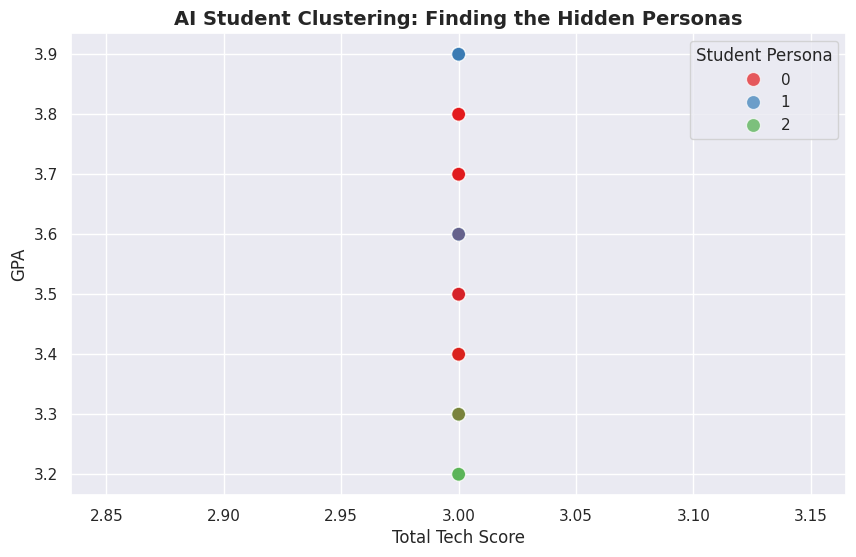


--- 2. THE CAREER RECOMMENDATION ENGINE ---

🎓 For a student with 3.9 GPA, 1 Project Word Count, and 15 Tech Score:
--------------------------------------------------
Based on mathematically similar alumni, the AI recommends:
 Machine Learning Engineer (AI Confidence: 40%)
 DevOps Engineer (AI Confidence: 20%)
 Cloud Solutions Architect (AI Confidence: 20%)
 NLP Engineer (AI Confidence: 20%)

🎓 For a student with 2.8 GPA, 8 Project Word Count, and 28 Tech Score:
--------------------------------------------------
Based on mathematically similar alumni, the AI recommends:
 Cloud Solutions Architect (AI Confidence: 20%)
 Blockchain Engineer (AI Confidence: 20%)
 Mobile App Developer (AI Confidence: 20%)
 Database Administrator (AI Confidence: 20%)
 Software Engineer (AI Confidence: 20%)


In [33]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

print("--- 1. STUDENT PERSONA CLUSTERING (K-MEANS) ---")

# Selecting the features the AI will use to judge the students
cluster_features = ['GPA', 'Project_Description_Length', 'Total_Tech_Score']
cluster_data = df[cluster_features].dropna().copy()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
cluster_data['Persona_ID'] = kmeans.fit_predict(scaled_data)

persona_summary = cluster_data.groupby('Persona_ID').mean()
print("📊 AI Discovered Student Personas (Averages):")
print(persona_summary)

# Visualizing the Tribes
plt.figure(figsize=(10, 6))
# Plotting Tech Score vs GPA, colored by the AI's chosen Persona
sns.scatterplot(x='Total_Tech_Score', y='GPA', hue='Persona_ID', data=cluster_data, palette='Set1', s=100, alpha=0.7)
plt.title('AI Student Clustering: Finding the Hidden Personas', fontsize=14, fontweight='bold')
plt.xlabel('Total Tech Score', fontsize=12)
plt.ylabel('GPA', fontsize=12)
plt.legend(title='Student Persona')
plt.show()


print("\n--- 2. THE CAREER RECOMMENDATION ENGINE ---")

rec_data = df.dropna(subset=['GPA', 'Project_Description_Length', 'Total_Tech_Score', 'Future Career']).copy()
rec_features = rec_data[['GPA', 'Project_Description_Length', 'Total_Tech_Score']]

# Scaling the data again for the recommendation engine
rec_scaled = scaler.fit_transform(rec_features)

# Building the Recommendation Engine (Finding the 5 closest students)
recommender = NearestNeighbors(n_neighbors=5, metric='euclidean')
recommender.fit(rec_scaled)

def recommend_career(gpa, project_description_length, tech_score):
    # Scaling the new student's input using our existing scaler
    student_profile = scaler.transform([[gpa, project_description_length, tech_score]])

    # Finding the mathematically closest students
    distances, indices = recommender.kneighbors(student_profile)

    # Extracting the careers of those matching students
    recommended_careers = rec_data.iloc[indices[0]]['Future Career'].value_counts()

    print(f"\n🎓 For a student with {gpa} GPA, {project_description_length} Project Word Count, and {tech_score} Tech Score:")
    print("-" * 50)
    print("Based on mathematically similar alumni, the AI recommends:")
    for career, count in recommended_careers.items():
        # Calculating the confidence based on how many neighbors had this career
        confidence = (count / 5) * 100
        print(f" {career} (AI Confidence: {confidence:.0f}%)")

# Student A: 3.9 GPA, 1 Project, 15 Tech Score (The Bookworm)
recommend_career(gpa=3.9, project_description_length=1, tech_score=15)

# Student B: 2.8 GPA, 8 Projects, 28 Tech Score (The Hacker/Builder)
recommend_career(gpa=2.8, project_description_length=8, tech_score=28)

# Thank You